# Notebook 3: NumPy — Advanced Math & Linear Algebra
### ML Skills Refresh Curriculum — Module 3 of 30

---

## 🎯 Learning Objectives

| # | Topic | Why It Matters in ML |
|---|-------|----------------------|
| 1 | Matrix Multiplication rules | Every forward pass in a neural network is a chain of matrix multiplications |
| 2 | `np.dot`, `np.matmul`, `@` | Three interchangeable tools — knowing all three prevents confusion when reading others' code |
| 3 | Broadcasting | Allows operations between arrays of different shapes without writing loops — essential for efficiency |
| 4 | Practical revenue example | Anchors the abstract algebra to a real-world business calculation |

---

> **Dataset Context:** We run a small retail chain — **3 stores** selling **4 products** (Coffee, Sandwich, Juice, Muffin). Our dataset is a **Quantities Sold matrix** (stores × products) and a **Prices vector** (one price per product). We will use matrix multiplication to compute **total daily revenue per store** in a single operation.

---
## Section 1 — The Mathematics of Matrix Multiplication

### 📖 The Logic — in Plain English

Before writing a single line of code, let's make sure the underlying math is completely clear.

#### What is a matrix?
A matrix is a 2-D grid of numbers arranged in **rows** and **columns**. We describe its size as **(rows × columns)**, called its **shape**. A vector is simply a special matrix with only one row or one column.

---

#### The Golden Rule of Matrix Multiplication

You can only multiply two matrices together **if the number of columns in the first matrix equals the number of rows in the second matrix**. This shared dimension is called the **inner dimension**.

```
  Matrix A         Matrix B          Result C
  shape (M, N)  @  shape (N, P)  =  shape (M, P)
                       ↑↑
              inner dimensions must match
```

The result matrix C has shape **(M, P)** — the two **outer** dimensions survive; the inner dimension disappears.

---

#### How each element of C is computed — the dot product

Each element `C[i, j]` is computed by taking **row i of A** and **column j of B**, multiplying them element-by-element, and summing the results:

```
C[i, j]  =  A[i, 0]*B[0, j]  +  A[i, 1]*B[1, j]  +  ...  +  A[i, N-1]*B[N-1, j]
```

**Worked example with tiny 2×2 matrices:**

```
A = [[1, 2],      B = [[5, 6],
     [3, 4]]           [7, 8]]

C[0,0] = 1*5 + 2*7 = 5  + 14 = 19
C[0,1] = 1*6 + 2*8 = 6  + 16 = 22
C[1,0] = 3*5 + 4*7 = 15 + 28 = 43
C[1,1] = 3*6 + 4*8 = 18 + 32 = 50

C = [[19, 22],
     [43, 50]]
```

---

#### Why does this matter in ML?

In a neural network's forward pass, the input data is a matrix of shape **(batch_size, n_features)**. The weight matrix of a layer has shape **(n_features, n_neurons)**. Their product gives **(batch_size, n_neurons)** — the activations for the entire batch in one shot. Understanding shape compatibility prevents 90 % of dimension-mismatch errors.

In [1]:
import numpy as np                 # core numerical computing library
import matplotlib.pyplot as plt    # plotting library for visualisations
import matplotlib.gridspec as gridspec  # fine-grained subplot layout control

# Set a global random seed so results are reproducible every time this notebook runs
np.random.seed(42)

---
## Section 2 — Verifying the Math by Hand

Let's reproduce the worked example above in NumPy so you can see that the numbers match exactly.

In [2]:
# ── Define the two 2×2 matrices from the worked example ───────────────────────
A = np.array([[1, 2],
              [3, 4]])   # shape (2, 2)

B = np.array([[5, 6],
              [7, 8]])   # shape (2, 2)

# ── Multiply using the @ operator (most readable, preferred in modern code) ───
C = A @ B                # equivalent to np.matmul(A, B) and np.dot(A, B) for 2-D

print("A =")
print(A)
print("\nB =")
print(B)
print("\nC = A @ B =")
print(C)

# ── Verify element C[0,0] manually ────────────────────────────────────────────
# C[0,0] = row 0 of A  ·  col 0 of B  =  1*5 + 2*7
manual_c00 = A[0, 0] * B[0, 0] + A[0, 1] * B[1, 0]   # 1*5 + 2*7
print(f"\nManual C[0,0] = {A[0,0]}×{B[0,0]} + {A[0,1]}×{B[1,0]} = {manual_c00}")
print(f"NumPy  C[0,0] = {C[0,0]}  ← matches ✓")

A =
[[1 2]
 [3 4]]

B =
[[5 6]
 [7 8]]

C = A @ B =
[[19 22]
 [43 50]]

Manual C[0,0] = 1×5 + 2×7 = 19
NumPy  C[0,0] = 19  ← matches ✓


---
## Section 3 — Shape Compatibility in Practice

### 📖 The Logic

Before multiplying two arrays, always check whether their shapes are compatible. A quick mental check:

```
  (M, N)  @  (N, P)  →  ✅ valid   result is (M, P)
  (M, N)  @  (M, P)  →  ❌ invalid — inner dims N ≠ M
```

The `.shape` attribute is your best friend here.

In [3]:
# ── Create arrays of various shapes and test compatibility ────────────────────
X = np.ones((3, 4))    # 3 rows, 4 cols — e.g. 3 samples, 4 features
W = np.ones((4, 2))    # 4 rows, 2 cols — e.g. weight matrix: 4 inputs → 2 neurons
Z = np.ones((5, 3))    # 5 rows, 3 cols — incompatible with X in the usual order

print(f"X shape: {X.shape}")
print(f"W shape: {W.shape}")
print(f"Z shape: {Z.shape}")

# ── Valid multiplication: (3,4) @ (4,2) → inner dims both 4 ──────────────────
result_valid = X @ W
print(f"\nX @ W  →  {X.shape} @ {W.shape} = {result_valid.shape}  ✅")

# ── Invalid multiplication: (3,4) @ (5,3) → inner dims 4 ≠ 5 ─────────────────
print("\nAttempting X @ Z  →  (3,4) @ (5,3) …")
try:
    result_invalid = X @ Z          # this will raise a ValueError
except ValueError as e:
    print(f"  ❌ ValueError: {e}")   # catch and print the error instead of crashing

X shape: (3, 4)
W shape: (4, 2)
Z shape: (5, 3)

X @ W  →  (3, 4) @ (4, 2) = (3, 2)  ✅

Attempting X @ Z  →  (3,4) @ (5,3) …
  ❌ ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 5 is different from 4)


---
## Section 4 — The Retail Dataset

### 📖 The Setup

Our retail chain has **3 stores** and sells **4 products**. Each day we record how many units of each product each store sold. We also have a price list — one price per product.

The goal: **calculate total daily revenue for each store** without writing a single Python loop.

```
Quantities matrix Q  →  shape (3, 4)   [stores × products]
Prices vector     p  →  shape (4,)     [one price per product]

Revenue per store    =  Q  @  p        →  shape (3,)   [one revenue figure per store]
```

The inner dimension (4 products) cancels out, leaving us with one number per store.

In [4]:
# ── Product catalogue ─────────────────────────────────────────────────────────
products = ["Coffee", "Sandwich", "Juice", "Muffin"]   # 4 products
stores   = ["Store A", "Store B", "Store C"]            # 3 stores

# ── Quantities Sold matrix: shape (3 stores, 4 products) ─────────────────────
# Row 0 = Store A, Row 1 = Store B, Row 2 = Store C
# Columns = Coffee, Sandwich, Juice, Muffin
Q = np.array([
    [120, 45, 30, 60],    # Store A units sold today
    [ 85, 70, 55, 40],    # Store B units sold today
    [200, 30, 80, 90],    # Store C units sold today
])                         # dtype inferred as int64

# ── Price vector: shape (4,) — one price per product ──────────────────────────
# Order must match the column order of Q: Coffee, Sandwich, Juice, Muffin
p = np.array([3.50, 6.00, 2.75, 2.25])   # prices in £

# ── Inspect shapes before multiplying — good habit ───────────────────────────
print(f"Quantities matrix Q  →  shape {Q.shape}  dtype {Q.dtype}")
print(f"Prices vector     p  →  shape {p.shape}  dtype {p.dtype}")

# ── Pretty-print the quantities table ────────────────────────────────────────
print("\n── Daily Units Sold ──")
print(f"{'':10}" + "".join(f"{prod:>12}" for prod in products))   # header row
for i, store in enumerate(stores):
    row_str = "".join(f"{Q[i, j]:>12}" for j in range(Q.shape[1]))
    print(f"{store:<10}" + row_str)

print("\n── Product Prices (£) ──")
for prod, price in zip(products, p):
    print(f"  {prod:<10}: £{price:.2f}")

Quantities matrix Q  →  shape (3, 4)  dtype int64
Prices vector     p  →  shape (4,)  dtype float64

── Daily Units Sold ──
                Coffee    Sandwich       Juice      Muffin
Store A            120          45          30          60
Store B             85          70          55          40
Store C            200          30          80          90

── Product Prices (£) ──
  Coffee    : £3.50
  Sandwich  : £6.00
  Juice     : £2.75
  Muffin    : £2.25


---
## Section 5 — Three Ways to Multiply: `np.dot`, `np.matmul`, and `@`

### 📖 The Logic

NumPy provides three tools for matrix multiplication. For 2-D arrays they produce **identical results** — the differences only emerge with higher-dimensional arrays.

| Tool | Syntax | Notes |
|------|--------|-------|
| `np.dot(A, b)` | Function call | For 2-D arrays behaves like matrix multiply. For 1-D arrays computes the scalar dot product. Avoid for 3-D+. |
| `np.matmul(A, B)` | Function call | Strictly matrix multiplication. Handles batches of matrices (3-D+) correctly. Does **not** accept scalars. |
| `A @ B` | Operator | Syntactic sugar for `np.matmul`. Most readable; **preferred** in modern code. |

> **Rule of thumb:** Always use `@` or `np.matmul`. Use `np.dot` only when explicitly computing a 1-D dot product (scalar result).

In [5]:
# ── Method 1: np.dot ──────────────────────────────────────────────────────────
# For a 2-D matrix and a 1-D vector, np.dot multiplies and sums along last axis of Q
revenue_dot    = np.dot(Q, p)

# ── Method 2: np.matmul ───────────────────────────────────────────────────────
# Strictly a matrix-multiply operation; treats the 1-D vector p as a column vector
revenue_matmul = np.matmul(Q, p)

# ── Method 3: @ operator ──────────────────────────────────────────────────────
# Cleanest syntax — calls np.matmul under the hood
revenue_at     = Q @ p

# ── All three must produce exactly the same result ────────────────────────────
print("Revenue via np.dot   :", revenue_dot)
print("Revenue via np.matmul:", revenue_matmul)
print("Revenue via @        :", revenue_at)
print(f"\nAll identical? {np.array_equal(revenue_dot, revenue_matmul) and np.array_equal(revenue_matmul, revenue_at)}  ✓")

# ── Report results per store ───────────────────────────────────────────────────
print("\n── Revenue per Store (£) ──")
for store, rev in zip(stores, revenue_at):    # zip pairs store name with its revenue
    print(f"  {store}: £{rev:,.2f}")

Revenue via np.dot   : [ 907.5   958.75 1302.5 ]
Revenue via np.matmul: [ 907.5   958.75 1302.5 ]
Revenue via @        : [ 907.5   958.75 1302.5 ]

All identical? True  ✓

── Revenue per Store (£) ──
  Store A: £907.50
  Store B: £958.75
  Store C: £1,302.50


### 🔍 Step-by-Step Walkthrough: How Store A's Revenue is Calculated

Let's manually reproduce `revenue_at[0]` (Store A) so you can see exactly what the `@` operator computed:

```
Store A row of Q:   [120,  45,  30,  60]
Prices vector  p:   [3.50, 6.00, 2.75, 2.25]

Revenue = 120×3.50  +  45×6.00  +  30×2.75  +  60×2.25
        =  420.00   +  270.00   +   82.50   +  135.00
        =  907.50
```

In [6]:
# ── Manual step-by-step replication of Store A's revenue ──────────────────────
store_a_row = Q[0]                   # extract row 0 (Store A): [120, 45, 30, 60]
element_products = store_a_row * p   # element-wise multiply: [420, 270, 82.5, 135]
store_a_revenue  = element_products.sum()   # sum all contributions

print("Store A quantities :", store_a_row)
print("Prices             :", p)
print("Element products   :", element_products)    # each product's revenue contribution
print(f"Sum (total revenue): £{store_a_revenue:,.2f}")
print(f"Matches Q @ p [0]? {np.isclose(store_a_revenue, revenue_at[0])}  ✓")

Store A quantities : [120  45  30  60]
Prices             : [3.5  6.   2.75 2.25]
Element products   : [420.  270.   82.5 135. ]
Sum (total revenue): £907.50
Matches Q @ p [0]? True  ✓


---
## Section 6 — Matrix × Matrix: Projecting Revenue Across Multiple Days

### 📖 The Logic

So far we multiplied a **(3,4) matrix by a (4,) vector** to get a **(3,)** revenue vector — one figure per store.

Now let's upgrade: what if we have **two different pricing scenarios** (normal prices vs. weekend premium prices) and we want to compute revenue under **both** scenarios simultaneously?

We encode both price vectors as columns in a **(4, 2) price matrix** P:

```
Q  @  P  =  Revenue matrix R
(3,4) @ (4,2)  =  (3,2)
      ↑↑
  inner dim = 4 products (matches)

Result R[i, j]  =  revenue of store i under pricing scenario j
```

In [7]:
# ── Two pricing scenarios stacked as columns in a (4, 2) matrix ───────────────
# Column 0 = weekday prices, Column 1 = weekend premium prices (+20%)
P = np.array([
    [3.50, 4.20],    # Coffee   : weekday £3.50, weekend £4.20
    [6.00, 7.20],    # Sandwich : weekday £6.00, weekend £7.20
    [2.75, 3.30],    # Juice    : weekday £2.75, weekend £3.30
    [2.25, 2.70],    # Muffin   : weekday £2.25, weekend £2.70
])                    # shape (4, 2)

print(f"Q shape: {Q.shape}   P shape: {P.shape}")
print(f"Expected result shape: ({Q.shape[0]}, {P.shape[1]})  ← (3 stores, 2 scenarios)")

# ── Perform the matrix multiplication ─────────────────────────────────────────
R = Q @ P            # (3,4) @ (4,2) = (3,2) — all stores, all scenarios at once

print(f"\nR shape: {R.shape}")
print("\n── Revenue Matrix R (£) ──")
scenarios = ["Weekday", "Weekend"]
print(f"{'':10}" + "".join(f"{s:>12}" for s in scenarios))  # header
for i, store in enumerate(stores):
    row_str = "".join(f"£{R[i, j]:>10,.2f}" for j in range(R.shape[1]))
    print(f"{store:<10}" + row_str)

# ── Show the uplift (weekend minus weekday) ────────────────────────────────────
uplift = R[:, 1] - R[:, 0]    # column 1 - column 0 for every row
print("\n── Weekend Revenue Uplift (£) ──")
for store, up in zip(stores, uplift):
    print(f"  {store}: +£{up:,.2f}")

Q shape: (3, 4)   P shape: (4, 2)
Expected result shape: (3, 2)  ← (3 stores, 2 scenarios)

R shape: (3, 2)

── Revenue Matrix R (£) ──
               Weekday     Weekend
Store A   £    907.50£  1,089.00
Store B   £    958.75£  1,150.50
Store C   £  1,302.50£  1,563.00

── Weekend Revenue Uplift (£) ──
  Store A: +£181.50
  Store B: +£191.75
  Store C: +£260.50


---
## Section 7 — Broadcasting

### 📖 The Logic — in Plain English

**Broadcasting** is NumPy's ability to perform arithmetic between arrays of *different shapes* by **implicitly stretching** the smaller array to match the larger one — without actually copying any data in memory.

#### Intuitive analogy
Imagine a spreadsheet with 3 rows (stores) and 4 columns (products). You want to add a 10 % tax to every number. You would type `=A1*1.10` in one cell and then drag it across all 12 cells. Broadcasting does that drag automatically.

---

#### The Broadcasting Rules (NumPy checks these left-to-right on the shapes)

1. If the two arrays have different numbers of dimensions, the shape of the **smaller** array is padded with 1s on the **left**.
2. Dimensions of size **1** are stretched to match the corresponding size of the other array.
3. If neither dimension is 1 and they are not equal → **error**.

---

#### Text-based example

```
Operation:  Q  +  discount_row

Q shape            :  (3, 4)
discount_row shape :       (4,)   ← NumPy pads to (1, 4)

After padding      :  (3, 4)
                      (1, 4)   ← the 1 is stretched to 3

Effective operation:  (3, 4)
                      (3, 4)   ← broadcast complete, element-wise add
```

NumPy acts **as if** it stacked 3 copies of `discount_row` on top of each other, but it never actually does so — it is a zero-copy optimisation.

In [8]:
# ── Example 1: Scalar broadcast ───────────────────────────────────────────────
# A scalar (shape ()) is broadcast to match any array shape.
# Real-world use: apply a uniform tax multiplier to every price.

tax_multiplier = 1.20          # 20% VAT added to all products
Q_with_tax = Q * tax_multiplier  # scalar is broadcast across all (3,4) elements

print("Original Q (units × price, no tax):")
print(Q)
print("\nQ × 1.20 (20% VAT applied via scalar broadcast):")
print(Q_with_tax)

Original Q (units × price, no tax):
[[120  45  30  60]
 [ 85  70  55  40]
 [200  30  80  90]]

Q × 1.20 (20% VAT applied via scalar broadcast):
[[144.  54.  36.  72.]
 [102.  84.  66.  48.]
 [240.  36.  96. 108.]]


In [9]:
# ── Example 2: 1-D vector broadcast along rows ────────────────────────────────
# Each product has a different discount applied to its sales count.
# discount_per_product shape is (4,) — broadcast to (3,4) automatically.

# A '10% demand uplift' estimate per product (e.g. after a marketing campaign)
demand_uplift = np.array([1.10, 1.05, 1.20, 1.15])   # shape (4,)

# NumPy stretches demand_uplift from (4,) → (1,4) → (3,4)
# then multiplies element-wise — each store's product count is scaled differently
Q_uplifted = Q * demand_uplift    # broadcast: (3,4) * (4,) → (3,4)

print(f"Q shape           : {Q.shape}")
print(f"demand_uplift shape: {demand_uplift.shape}  → broadcast to (3,4)")
print(f"Q_uplifted shape  : {Q_uplifted.shape}")
print("\nOriginal Q:")
print(Q)
print("\nQ after demand uplift (×[1.10, 1.05, 1.20, 1.15] per product column):")
print(np.round(Q_uplifted, 1))   # round to 1 dp for readability

Q shape           : (3, 4)
demand_uplift shape: (4,)  → broadcast to (3,4)
Q_uplifted shape  : (3, 4)

Original Q:
[[120  45  30  60]
 [ 85  70  55  40]
 [200  30  80  90]]

Q after demand uplift (×[1.10, 1.05, 1.20, 1.15] per product column):
[[132.   47.2  36.   69. ]
 [ 93.5  73.5  66.   46. ]
 [220.   31.5  96.  103.5]]


In [10]:
# ── Example 3: Column vector broadcast along columns ─────────────────────────
# Each STORE has a different overall performance multiplier.
# For this we need a column vector of shape (3, 1) — not (3,).

# Store performance factors (e.g. based on footfall index)
store_factor = np.array([[0.90],   # Store A — quieter area, 10% below average
                          [1.00],   # Store B — average traffic
                          [1.15]])  # Store C — flagship, 15% above average
# shape (3, 1) ← the explicit 1 in the column position makes broadcasting work row-wise

# NumPy stretches store_factor from (3,1) → (3,4)
# then multiplies: each row of Q is scaled by that store's factor
Q_adjusted = Q * store_factor    # broadcast: (3,4) * (3,1) → (3,4)

print(f"Q shape           : {Q.shape}")
print(f"store_factor shape: {store_factor.shape}  → broadcast to (3,4)")
print("\nOriginal Q:")
print(Q)
print("\nQ after store factor adjustment:")
print(np.round(Q_adjusted, 1))

# ── Compute adjusted revenue with the same @ trick ────────────────────────────
revenue_adjusted = Q_adjusted @ p    # (3,4) @ (4,) = (3,)
print("\n── Adjusted Revenue per Store (£) ──")
for store, rev_orig, rev_adj in zip(stores, revenue_at, revenue_adjusted):
    delta = rev_adj - rev_orig
    sign  = "+" if delta >= 0 else ""   # add + sign for positive deltas
    print(f"  {store}: original £{rev_orig:>7,.2f}  →  adjusted £{rev_adj:>8,.2f}  ({sign}£{delta:,.2f})")

Q shape           : (3, 4)
store_factor shape: (3, 1)  → broadcast to (3,4)

Original Q:
[[120  45  30  60]
 [ 85  70  55  40]
 [200  30  80  90]]

Q after store factor adjustment:
[[108.   40.5  27.   54. ]
 [ 85.   70.   55.   40. ]
 [230.   34.5  92.  103.5]]

── Adjusted Revenue per Store (£) ──
  Store A: original £ 907.50  →  adjusted £  816.75  (£-90.75)
  Store B: original £ 958.75  →  adjusted £  958.75  (+£0.00)
  Store C: original £1,302.50  →  adjusted £1,497.88  (+£195.38)


### ⚠️ When Broadcasting Fails

Broadcasting only works when the mismatched dimensions are **exactly 1**. A shape of `(3,)` cannot broadcast against a `(3, 4)` array in the column direction because the 3 doesn't match the 4. You must explicitly reshape it to `(3, 1)` first.

In [11]:
# ── Wrong: a flat (3,) vector cannot broadcast column-wise against (3,4) ──────
store_factor_wrong = np.array([0.90, 1.00, 1.15])   # shape (3,) — not (3,1)
print(f"store_factor_wrong shape: {store_factor_wrong.shape}")

print("\nAttempting Q * store_factor_wrong  →  (3,4) * (3,) …")
try:
    Q * store_factor_wrong    # trailing dims: 4 ≠ 3 → error
except ValueError as e:
    print(f"  ❌ ValueError: {e}")

# ── Fix: reshape (3,) to (3,1) using np.reshape or [:, np.newaxis] ────────────
store_factor_fixed = store_factor_wrong[:, np.newaxis]   # add a new axis → (3,1)
print(f"\nAfter reshape: {store_factor_wrong.shape} → {store_factor_fixed.shape}")
result = Q * store_factor_fixed    # now (3,4) * (3,1) broadcasts correctly → (3,4)
print(f"Q * store_factor_fixed shape: {result.shape}  ✅")

store_factor_wrong shape: (3,)

Attempting Q * store_factor_wrong  →  (3,4) * (3,) …
  ❌ ValueError: operands could not be broadcast together with shapes (3,4) (3,) 

After reshape: (3,) → (3, 1)
Q * store_factor_fixed shape: (3, 4)  ✅


---
## Section 8 — Useful `np.linalg` Tools

### 📖 The Logic

NumPy bundles a `linalg` sub-module with standard linear algebra operations. The three most frequently used in ML are:

| Function | What it computes | ML use-case |
|----------|-----------------|-------------|
| `np.linalg.norm` | Length/magnitude of a vector | Regularisation, similarity metrics |
| `np.linalg.inv` | Matrix inverse | Analytical least-squares solution |
| `np.linalg.det` | Determinant of a matrix | Checking if a matrix is invertible |

In [12]:
# ── np.linalg.norm: Euclidean length of the price vector ──────────────────────
# The L2 norm = sqrt(sum of squares) — measures how 'large' a vector is overall
price_norm = np.linalg.norm(p)    # sqrt(3.5² + 6² + 2.75² + 2.25²)
print(f"L2 norm of price vector p: {price_norm:.4f}")

# ── Manual verification ────────────────────────────────────────────────────────
manual_norm = np.sqrt(np.sum(p ** 2))   # square each element, sum, then sqrt
print(f"Manual L2 norm            : {manual_norm:.4f}  ← matches ✓")

# ── np.linalg.det: determinant of a square matrix ────────────────────────────
# A non-zero determinant means the matrix is invertible (full rank)
M = np.array([[2.0, 1.0],
              [5.0, 3.0]])    # a 2×2 square matrix
det_M = np.linalg.det(M)
print(f"\nMatrix M:\n{M}")
print(f"det(M) = {det_M:.4f}  ({'invertible ✅' if abs(det_M) > 1e-10 else 'singular ❌'})")

# ── np.linalg.inv: matrix inverse ─────────────────────────────────────────────
# M_inv exists only because det(M) ≠ 0
# Property: M @ M_inv should equal the identity matrix I (1s on diagonal, 0s elsewhere)
M_inv = np.linalg.inv(M)
print(f"\nM_inv:\n{M_inv}")

# Verify: M @ M_inv ≈ identity
identity_check = M @ M_inv
print(f"\nM @ M_inv (should be identity matrix):")
print(np.round(identity_check, 10))   # round to remove floating-point noise

L2 norm of price vector p: 7.8022
Manual L2 norm            : 7.8022  ← matches ✓

Matrix M:
[[2. 1.]
 [5. 3.]]
det(M) = 1.0000  (invertible ✅)

M_inv:
[[ 3. -1.]
 [-5.  2.]]

M @ M_inv (should be identity matrix):
[[ 1.  0.]
 [-0.  1.]]


---
## Section 9 — Visualisation

### 📖 What We Are Plotting

Four panels that make the notebook's key concepts visual:

1. **Revenue per Store (Weekday vs Weekend)** — grouped bar chart of the matrix multiplication result R.
2. **Product Contribution to Store A Revenue** — pie chart showing which products drive the most revenue.
3. **Broadcasting Demo (before vs after tax)** — heatmaps of Q and Q_with_tax side by side.
4. **Shape Compatibility Reference** — a static diagram summarising the (M,N)@(N,P)=(M,P) rule.

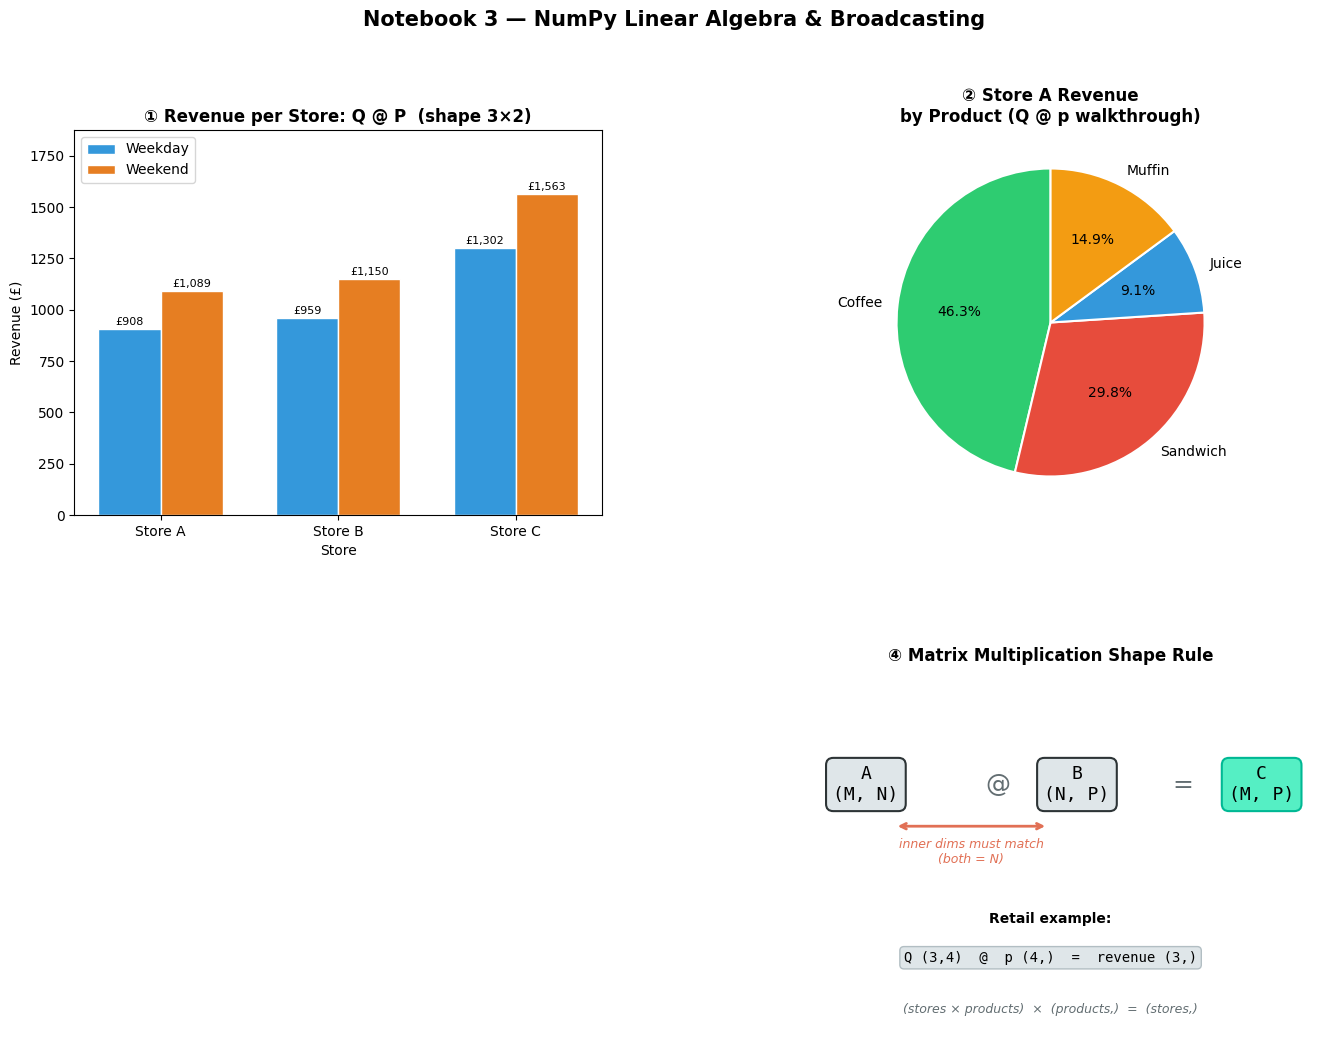


📊 Reading the panels:
  ① Grouped bars show how the same Q matrix produces different revenues
     when multiplied by a 2-column price matrix (weekday vs weekend).
  ② Pie chart decomposes Store A's revenue into per-product contributions,
     mirroring the dot-product walkthrough in Section 5.
  ③ Heatmaps show that scalar broadcasting (×1.20) scales every cell
     uniformly — notice the uniform colour shift from left to right.
  ④ Reference card for the shape rule — keep it in mind every time
     you get a dimension mismatch error.



In [13]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle("Notebook 3 — NumPy Linear Algebra & Broadcasting",
             fontsize=15, fontweight="bold", y=0.98)

# Use GridSpec for a 2×2 layout with breathing room
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.40, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])   # top-left
ax2 = fig.add_subplot(gs[0, 1])   # top-right
ax3 = fig.add_subplot(gs[1, 0])   # bottom-left
ax4 = fig.add_subplot(gs[1, 1])   # bottom-right

# ─── Panel 1: Grouped bar — Weekday vs Weekend revenue ───────────────────────
x      = np.arange(len(stores))   # [0, 1, 2] — one group per store
width  = 0.35                      # width of each bar in a group

bars1 = ax1.bar(x - width/2, R[:, 0], width,   # weekday bars shifted LEFT
                label="Weekday", color="#3498db", edgecolor="white")
bars2 = ax1.bar(x + width/2, R[:, 1], width,   # weekend bars shifted RIGHT
                label="Weekend", color="#e67e22", edgecolor="white")

# Annotate bars with revenue values
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width() / 2,   # centre of bar
             bar.get_height() + 10,                # just above bar top
             f"£{bar.get_height():,.0f}",
             ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 10,
             f"£{bar.get_height():,.0f}",
             ha="center", va="bottom", fontsize=8)

ax1.set_title("① Revenue per Store: Q @ P  (shape 3×2)", fontweight="bold")
ax1.set_xlabel("Store")
ax1.set_ylabel("Revenue (£)")
ax1.set_xticks(x)
ax1.set_xticklabels(stores)
ax1.legend()
ax1.set_ylim(0, max(R.flatten()) * 1.20)   # 20% headroom for annotations

# ─── Panel 2: Pie chart — Product contribution to Store A revenue ─────────────
store_a_contributions = Q[0] * p    # element-wise: units × price per product
pie_colors = ["#2ecc71", "#e74c3c", "#3498db", "#f39c12"]

ax2.pie(
    store_a_contributions,
    labels=products,
    autopct="%1.1f%%",          # show percentage labels
    colors=pie_colors,
    startangle=90,              # start first slice at 12 o'clock
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
ax2.set_title("② Store A Revenue\nby Product (Q @ p walkthrough)", fontweight="bold")

# ─── Panel 3: Side-by-side heatmaps — broadcasting demo ───────────────────────
# Show Q and Q_with_tax as colour grids to make the uniform scaling visible

# We'll split the bottom-left axis into two sub-axes manually
ax3.set_visible(False)   # hide original axis — we'll draw inside its bounding box

# Create two inset axes within the bottom-left grid cell
left_pos  = [0.05, 0.08, 0.40, 0.80]   # [left, bottom, width, height] in axes coords
right_pos = [0.55, 0.08, 0.40, 0.80]

ax3a = ax3.inset_axes(left_pos)
ax3b = ax3.inset_axes(right_pos)

vmin = Q.min()              # common colour scale so heatmaps are comparable
vmax = Q_with_tax.max()

im1 = ax3a.imshow(Q,           cmap="Blues", vmin=vmin, vmax=vmax, aspect="auto")
im2 = ax3b.imshow(Q_with_tax,  cmap="Blues", vmin=vmin, vmax=vmax, aspect="auto")

# Label axes with product/store names
for ax_h, title in [(ax3a, "Original Q"), (ax3b, "Q × 1.20 (20% VAT)")]:
    ax_h.set_xticks(range(4))
    ax_h.set_xticklabels([p[:3] for p in products], fontsize=7)  # shorten labels
    ax_h.set_yticks(range(3))
    ax_h.set_yticklabels(stores, fontsize=7)
    ax_h.set_title(title, fontsize=8, fontweight="bold")

# Annotate cells with values
for i in range(3):
    for j in range(4):
        ax3a.text(j, i, str(Q[i, j]),           ha="center", va="center", fontsize=7, color="white")
        ax3b.text(j, i, f"{Q_with_tax[i,j]:.0f}", ha="center", va="center", fontsize=7, color="white")

ax3.set_title("③ Broadcasting: Scalar × Matrix Heatmaps", fontweight="bold", pad=12)

# ─── Panel 4: Shape rule reference diagram ────────────────────────────────────
ax4.set_xlim(0, 10)
ax4.set_ylim(0, 6)
ax4.axis("off")   # no axes — this is a text/diagram panel
ax4.set_title("④ Matrix Multiplication Shape Rule", fontweight="bold")

# Draw shape boxes
box_style = dict(boxstyle="round,pad=0.4", facecolor="#dfe6e9", edgecolor="#2d3436", linewidth=1.5)

ax4.text(1.5, 4.2, "A\n(M, N)",   ha="center", va="center", fontsize=13,
         fontfamily="monospace", bbox=box_style)
ax4.text(4.0, 4.2, "@",            ha="center", va="center", fontsize=18, color="#636e72")
ax4.text(5.5, 4.2, "B\n(N, P)",   ha="center", va="center", fontsize=13,
         fontfamily="monospace", bbox=box_style)
ax4.text(7.5, 4.2, "=",            ha="center", va="center", fontsize=18, color="#636e72")
ax4.text(9.0, 4.2, "C\n(M, P)",   ha="center", va="center", fontsize=13,
         fontfamily="monospace",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="#55efc4", edgecolor="#00b894", linewidth=1.5))

# Arrow showing inner dims must match
ax4.annotate("", xy=(5.5-0.55, 3.55), xytext=(1.5+0.55, 3.55),
             arrowprops=dict(arrowstyle="<->", color="#e17055", lw=2.0))
ax4.text(3.5, 3.15, "inner dims must match\n(both = N)",
         ha="center", va="center", fontsize=9, color="#e17055", fontstyle="italic")

# Retail example below
ax4.text(5.0, 2.1,
         "Retail example:",
         ha="center", va="center", fontsize=10, fontweight="bold")
ax4.text(5.0, 1.5,
         "Q (3,4)  @  p (4,)  =  revenue (3,)",
         ha="center", va="center", fontsize=10, fontfamily="monospace",
         bbox=dict(boxstyle="round", facecolor="#dfe6e9", edgecolor="#b2bec3"))
ax4.text(5.0, 0.7,
         "(stores × products)  ×  (products,)  =  (stores,)",
         ha="center", va="center", fontsize=9, color="#636e72", fontstyle="italic")

plt.savefig("/tmp/nb3_preview.png", dpi=100, bbox_inches="tight")  # optional save
plt.show()

print("""
📊 Reading the panels:
  ① Grouped bars show how the same Q matrix produces different revenues
     when multiplied by a 2-column price matrix (weekday vs weekend).
  ② Pie chart decomposes Store A's revenue into per-product contributions,
     mirroring the dot-product walkthrough in Section 5.
  ③ Heatmaps show that scalar broadcasting (×1.20) scales every cell
     uniformly — notice the uniform colour shift from left to right.
  ④ Reference card for the shape rule — keep it in mind every time
     you get a dimension mismatch error.
""")

---
## ✅ Notebook Summary & Key Takeaways

| Concept | Core rule | Gotcha to remember |
|---------|-----------|--------------------|
| **Matrix multiply** | Inner dims must match: `(M,N) @ (N,P) = (M,P)` | `@` is preferred over `np.dot` for matrices |
| **`np.dot`** | Scalar dot product for 1-D; matrix multiply for 2-D | Avoid for 3-D+ arrays — use `np.matmul` instead |
| **`np.matmul` / `@`** | Always matrix multiplication; never broadcasts scalars | Use these by default |
| **Broadcasting (scalar)** | `(M,N) * scalar` → stretches scalar to `(M,N)` | No data is copied — it's a zero-cost trick |
| **Broadcasting (1-D row)** | `(M,N) * (N,)` → row vector applied to every row | Shape `(N,)` is treated as `(1,N)` automatically |
| **Broadcasting (1-D col)** | `(M,N) * (M,1)` → column vector applied to every col | Must reshape `(M,)` → `(M,1)` manually first |
| **`np.linalg.norm`** | L2 magnitude of a vector | Used in regularisation and distance metrics |
| **`np.linalg.inv`** | Inverse only exists when `det ≠ 0` | Rarely needed in practice — solvers are safer |

---
